# SPID inverted-pendulum: reward-bootstrap 10-seed analysis

This notebook analyzes the 10-seed ANN-to-CGP SPID experiment with guarded aggregation, reward-guided repertoire bootstrapping, fast expert annealing, and rollout validation at CGP generations 10, 30, and 50. It loads every result from the directory containing the notebook.

In [8]:
from pathlib import Path
import json
import pickle

import jax
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (10, 5), "figure.dpi": 120})

run_dir = Path.cwd()
if not (run_dir / "config.json").exists():
    matches = list(Path.cwd().rglob("ann_reward_bootstrap_ten_seeds/config.json"))
    if not matches:
        raise FileNotFoundError("Could not locate ann_reward_bootstrap_ten_seeds/config.json")
    run_dir = matches[0].parent

config = json.loads((run_dir / "config.json").read_text())
summary = json.loads((run_dir / "aggregate_summary.json").read_text())
aggregate = pd.DataFrame(summary["seeds"]).sort_values("seed").reset_index(drop=True)
metrics = pd.concat([
    pd.read_csv(path).assign(seed=int(path.parent.name.split("_")[1]))
    for path in sorted(run_dir.glob("seed_*/metrics.csv"))
], ignore_index=True)
print(f"Loaded {len(aggregate)} seeds and {len(metrics)} iterations from {run_dir}")
display(pd.Series(config, name="value").to_frame())

Loaded 10 seeds and 145 iterations from /home/gnadizar/PycharmProjects/genepax/distillation_experiments/repertoires/spid_inverted_pendulum/ann_reward_bootstrap_ten_seeds


,value
aggregation_policy,best
backend,generalized
dataset_batch_size,2048
env,inverted_pendulum
evaluation_trajectories,10
expert_anneal_iterations,9
expert_fraction,0.25
expert_weight_end,0.0
expert_weight_start,0.8
gm_alpha,0.1


## Aggregate outcome

,value
completed seeds,10.000000
solved seeds,1.000000
solve rate,0.100000
mean best reward,376.060010
median best reward,288.050018


,seed,best_validation_reward,best_iteration,last_iteration,solved
0,0,273.300018,12,14,False
1,1,245.600006,2,14,False
2,2,302.800018,3,14,False
3,3,307.500000,9,14,False
4,4,236.199997,7,14,False
5,5,258.200012,8,14,False
6,6,1000.000000,9,9,True
7,7,244.300003,9,14,False
8,8,577.900024,8,14,False
9,9,314.800018,2,14,False


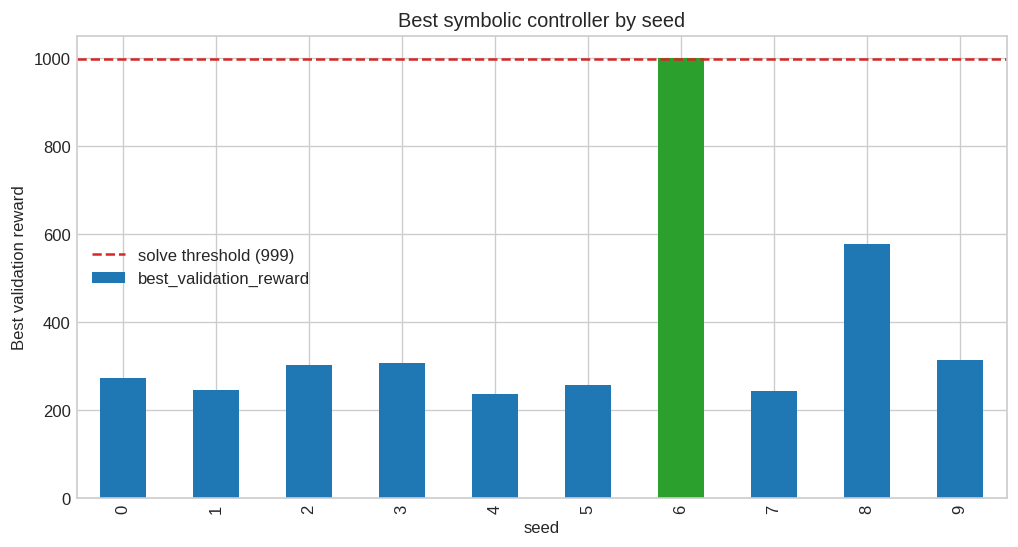

In [9]:
target = config["target_reward"]
outcome = pd.Series({
    "completed seeds": summary["completed_seeds"],
    "solved seeds": summary["solved_seeds"],
    "solve rate": aggregate["solved"].mean(),
    "mean best reward": aggregate["best_validation_reward"].mean(),
    "median best reward": aggregate["best_validation_reward"].median(),
})
display(outcome.to_frame("value"))
display(aggregate[["seed", "best_validation_reward", "best_iteration", "last_iteration", "solved"]])

colors = np.where(aggregate["solved"], "tab:green", "tab:blue")
ax = aggregate.plot.bar(x="seed", y="best_validation_reward", color=colors, legend=False)
ax.axhline(target, color="tab:red", linestyle="--", label=f"solve threshold ({target:g})")
ax.set(ylabel="Best validation reward", title="Best symbolic controller by seed")
ax.legend()
plt.show()

## Learning curves and expert withdrawal

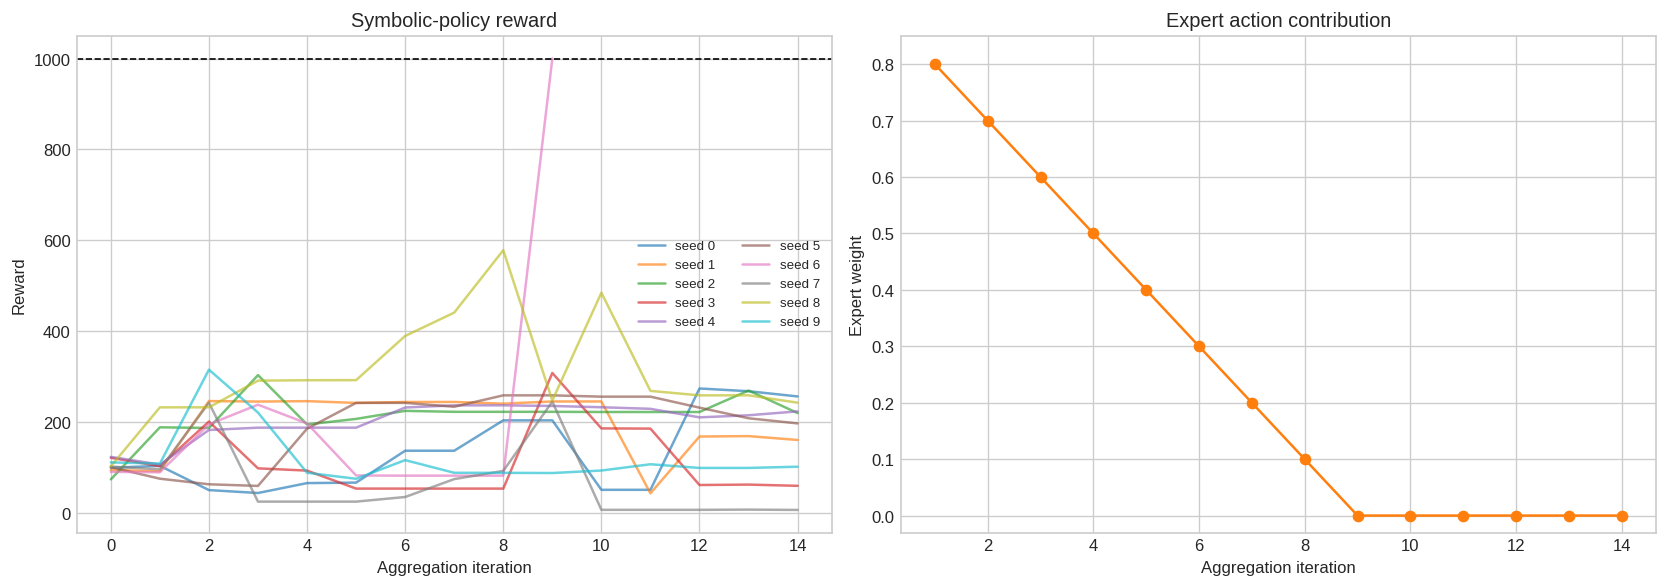

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for seed, frame in metrics.groupby("seed"):
    axes[0].plot(frame["iteration"], frame["symbolic_reward"], alpha=0.65, label=f"seed {seed}")
axes[0].axhline(target, color="black", linestyle="--", linewidth=1)
axes[0].set(title="Symbolic-policy reward", xlabel="Aggregation iteration", ylabel="Reward")
axes[0].legend(ncol=2, fontsize=8)

schedule = metrics.dropna(subset=["expert_weight"]).groupby("iteration")["expert_weight"].first()
axes[1].plot(schedule.index, schedule.values, marker="o", color="tab:orange")
axes[1].set(title="Expert action contribution", xlabel="Aggregation iteration", ylabel="Expert weight", ylim=(-0.03, 0.85))
plt.tight_layout()
plt.show()

## Loss–reward alignment

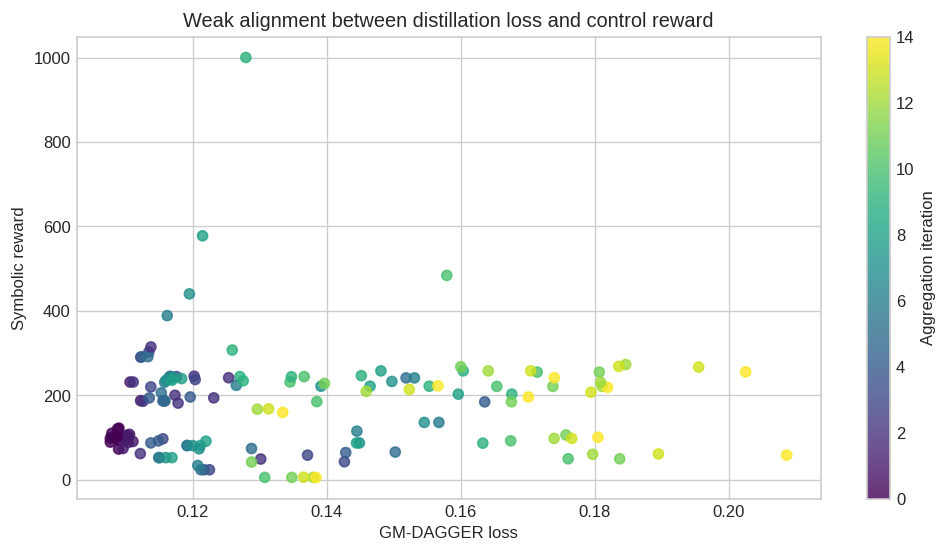

Pearson correlation: 0.06373008143292341
Spearman correlation: 0.12022970084682703


In [11]:
finite = metrics[np.isfinite(metrics["gm_loss"]) & np.isfinite(metrics["symbolic_reward"])].copy()
fig, ax = plt.subplots()
scatter = ax.scatter(finite["gm_loss"], finite["symbolic_reward"], c=finite["iteration"], cmap="viridis", alpha=0.8)
ax.set(xlabel="GM-DAGGER loss", ylabel="Symbolic reward", title="Weak alignment between distillation loss and control reward")
fig.colorbar(scatter, ax=ax, label="Aggregation iteration")
plt.show()
print("Pearson correlation:", finite[["gm_loss", "symbolic_reward"]].corr().iloc[0, 1])
print("Spearman correlation:", finite[["gm_loss", "symbolic_reward"]].corr(method="spearman").iloc[0, 1])

## Validation checkpoints inside CGP search

,count,mean,median,max
generation,,,,
10,145,154.575175,159.300003,484.200012
30,145,141.988279,107.900002,577.900024
50,145,153.630347,136.199997,1000.000000


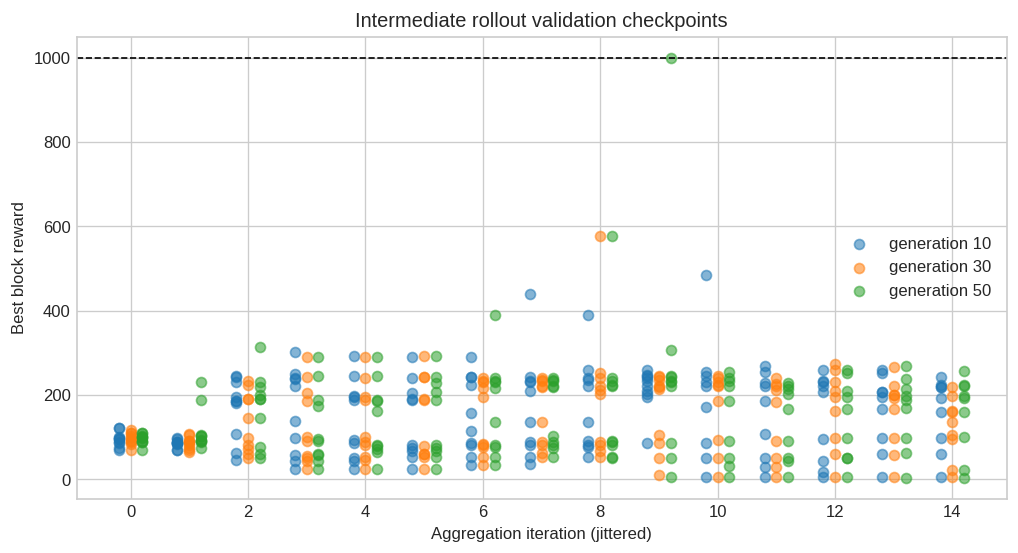

In [12]:
block_rows = []
for path in sorted(run_dir.glob("seed_*/iterations/iteration_*/metadata.json")):
    metadata = json.loads(path.read_text())
    seed = int(path.parents[2].name.split("_")[1])
    for block in metadata.get("block_validations", []):
        block_rows.append({"seed": seed, "iteration": metadata["iteration"], **block})
blocks = pd.DataFrame(block_rows)
display(blocks.groupby("generation")["reward"].agg(["count", "mean", "median", "max"]))

fig, ax = plt.subplots()
for generation, frame in blocks.groupby("generation"):
    ax.scatter(frame["iteration"] + (generation - 30) / 100, frame["reward"], alpha=0.55, label=f"generation {generation}")
ax.axhline(target, color="black", linestyle="--", linewidth=1)
ax.set(xlabel="Aggregation iteration (jittered)", ylabel="Best block reward", title="Intermediate rollout validation checkpoints")
ax.legend()
plt.show()

## Held-out confirmation of the solved controller

,controller,training_seed,best_iteration,evaluation_seed_start,num_trajectories,rollout_steps,mean_reward,median_reward,std_reward,min_reward,max_reward,solved_fraction
0,best_genotype.pickle,6,9,300000,100,1000,1000.0,1000.0,0.0,1000.0,1000.0,1.0


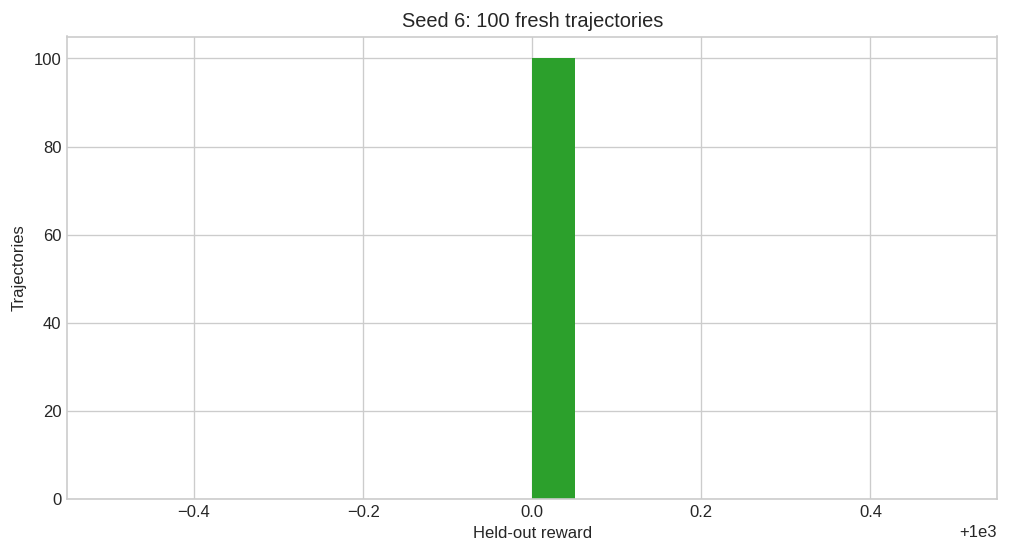

In [13]:
heldout_paths = sorted(run_dir.glob("seed_*/heldout_evaluation_100.json"))
heldout_rows = []
for path in heldout_paths:
    result = json.loads(path.read_text())
    heldout_rows.append({key: value for key, value in result.items() if key != "rewards"})
heldout = pd.DataFrame(heldout_rows)
display(heldout)
if heldout_paths:
    result = json.loads(heldout_paths[0].read_text())
    plt.hist(result["rewards"], bins=20, color="tab:green")
    plt.xlabel("Held-out reward")
    plt.ylabel("Trajectories")
    plt.title(f"Seed {result['training_seed']}: {result['num_trajectories']} fresh trajectories")
    plt.show()

## Best symbolic expressions

In [14]:
from genepax.gp.cartesian_genetic_programming import CGP

cgp = CGP(n_inputs=4, n_outputs=1)
input_names = {0: "cart_position", 1: "pole_angle", 2: "cart_velocity", 3: "pole_angular_velocity"}
output_names = {0: "action"}
expression_rows = []
for result in aggregate.itertuples(index=False):
    with (run_dir / f"seed_{result.seed}" / "best_genotype.pickle").open("rb") as file:
        genotype = pickle.load(file)
    expression_rows.append({
        "seed": result.seed,
        "best_iteration": result.best_iteration,
        "best_reward": result.best_validation_reward,
        "expression": cgp.get_readable_expression(genotype, inputs_mapping=input_names, outputs_mapping=output_names),
    })
expression_table = pd.DataFrame(expression_rows)
with pd.option_context("display.max_colwidth", None):
    display(expression_table.style.hide(axis="index").set_properties(subset=["expression"], **{"text-align": "left"}))

seed,best_iteration,best_reward,expression
0,12,273.300018,action = tanh(((exp(pole_angle)*exp(((cart_position+cos(cos(1.0)))powlog(((cart_velocity+pole_angle)/pole_angular_velocity)))))*pole_angle))
1,2,245.600006,action = tanh((pole_anglepowsin(sqrt(exp(cart_velocity)))))
2,3,302.800018,action = tanh((pole_angle*exp((pole_anglepow0.1))))
3,9,307.500000,action = tanh((pole_anglepow((abs(0.1)powcart_position)/((pole_angle+1.0)+log((pole_angle+1.0))))))
4,7,236.199997,action = tanh((pole_angle*exp((((sqrt(pole_angular_velocity)pow(abs(sqrt(pole_angular_velocity))/abs(sqrt(pole_angular_velocity))))-0.1)pow((pole_angular_velocity-pole_angle)+abs(cart_velocity))))))
5,8,258.200012,action = tanh(((((exp(pole_angle)-pole_angular_velocity)*(exp(pole_angle)-pole_angular_velocity))*pole_angle)/sqrt((sqrt(cart_position)+cart_velocity))))
6,9,1000.000000,action = tanh(((pole_angle*exp(abs(1.0)))+(cart_positionpow(exp(abs(1.0))-cart_position))))
7,9,244.300003,action = tanh(sin((((((pole_anglepow(0.1powpole_angle))+1.0)+id((pole_angle/1.0)))*((((pole_anglepow(0.1powpole_angle))+1.0)+id((pole_angle/1.0)))-id((pole_angle/1.0))))-((pole_anglepow(0.1powpole_angle))+1.0))))
8,8,577.900024,action = tanh((((((pole_angle+0.1)/exp(sin(1.0)))+pole_angular_velocity)*abs(((pole_angle+0.1)/exp(sin(1.0)))))+pole_angle))
9,2,314.800018,action = tanh(((exp(pole_angular_velocity)+(pole_anglepowabs(0.1)))*(pole_angle+pole_angle)))


## Fixed-dataset population audit

,seed,iteration,spearman_loss_reward,spearman_performance_gap_reward,best_reward,best_reward_loss_rank,best_loss_reward
0,0,12,-0.557994,-0.491291,284.550018,68,230.000000
1,1,2,-0.047675,-0.716657,246.250000,4,234.750000
2,2,3,-0.610127,-0.610127,288.250000,1,288.250000
3,3,9,0.561318,-0.899069,434.200012,69,51.600002
4,4,7,-0.035454,-0.776673,252.300003,1,249.800003
5,5,8,-0.346801,-1.000000,240.750000,1,240.750000
6,6,9,NaN,NaN,1000.000000,1,1000.000000
7,7,9,0.020408,0.020408,238.800003,3,5.050000
8,8,8,-0.903224,-0.873119,661.750000,6,660.600037
9,9,2,0.103014,-0.302818,288.950012,1,288.950012


/home/gnadizar/miniconda3/envs/gpax311/lib/python3.11/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


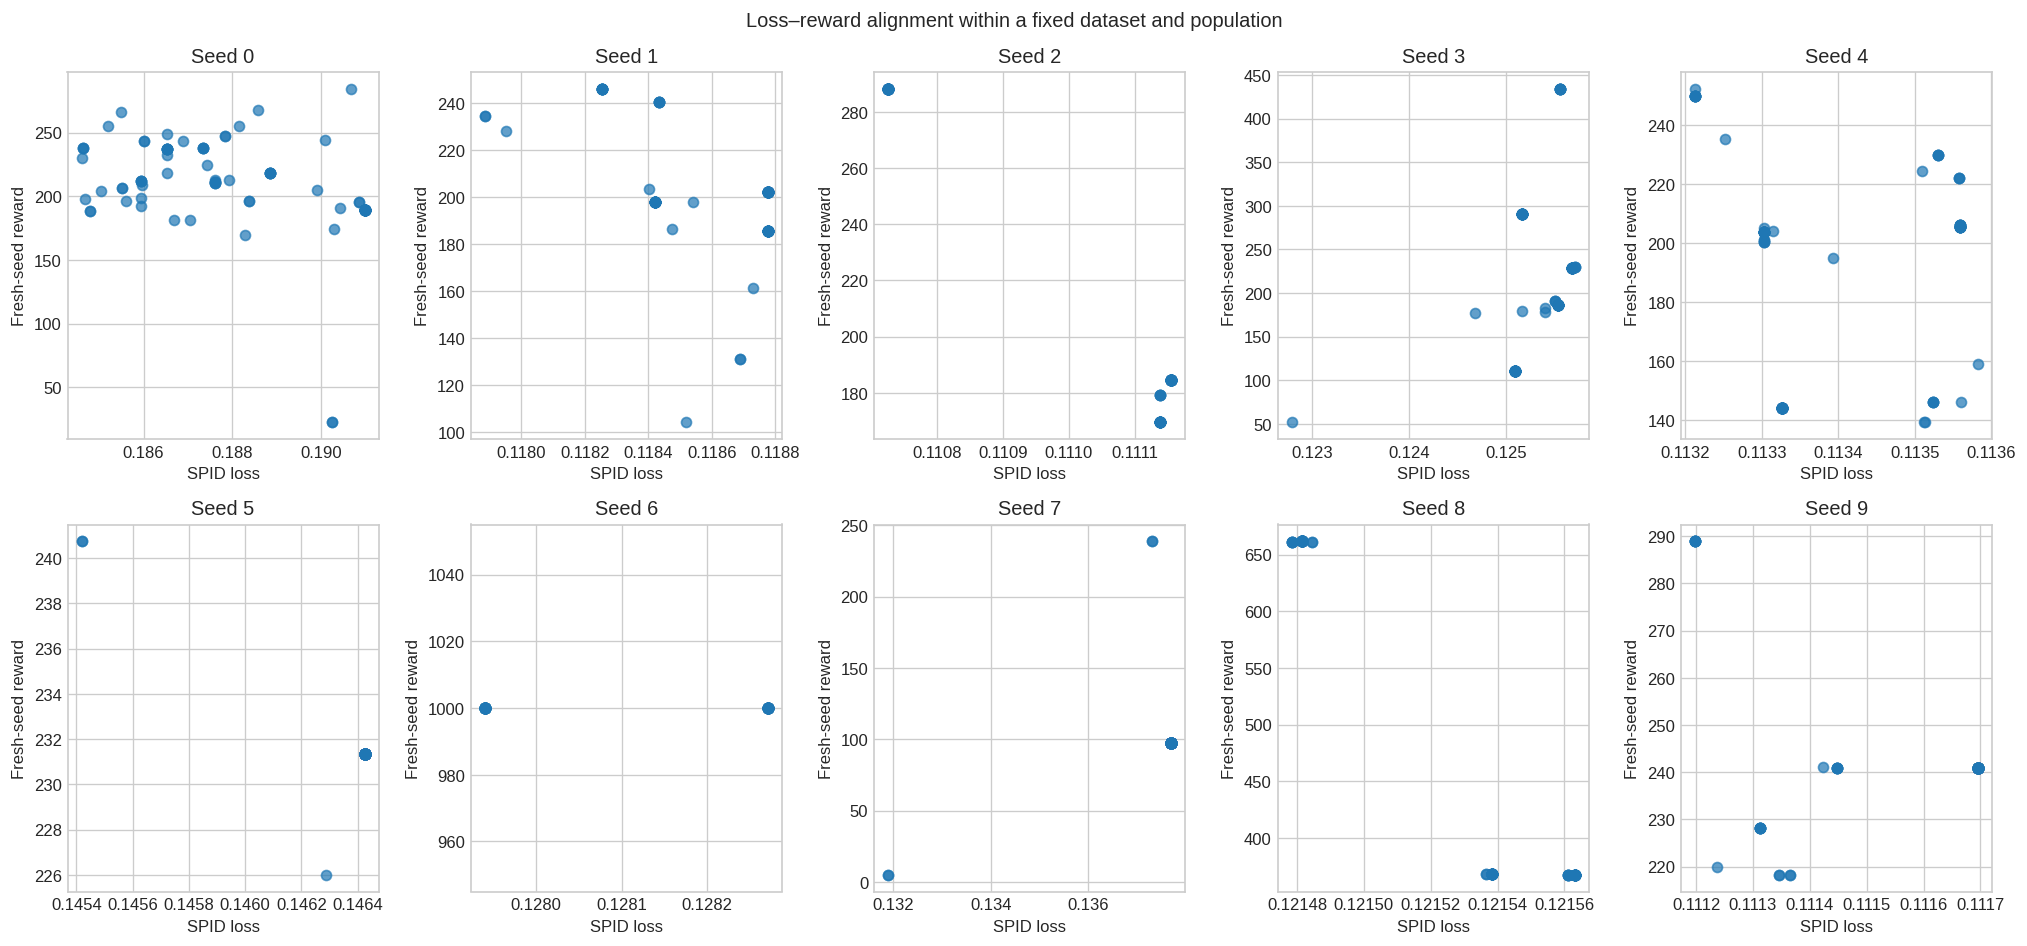

,GM loss,performance gap,fidelity gap
seed,,,
0,-0.557994,-0.491291,0.442287
1,-0.047675,-0.716657,0.825565
2,-0.610127,-0.610127,-0.949367
3,0.561318,-0.899069,0.427981
4,-0.035454,-0.776673,0.465775
5,-0.346801,-1.000000,1.000000
6,NaN,NaN,NaN
7,0.020408,0.020408,1.000000
8,-0.903224,-0.873119,0.695630


,median Spearman correlation
GM loss,-0.047675
performance gap,-0.716657
fidelity gap,0.465775


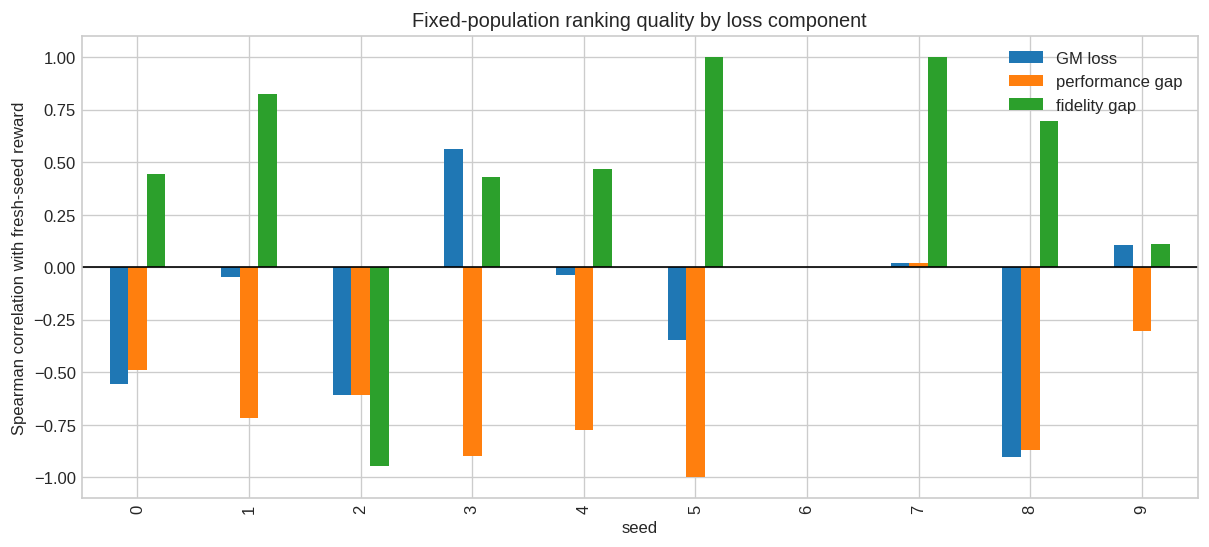

In [15]:
audit_path = run_dir / "population_audit" / "aggregate_summary.json"
audit_summary = pd.DataFrame(json.loads(audit_path.read_text()))
display(audit_summary[[
    "seed", "iteration", "spearman_loss_reward",
    "spearman_performance_gap_reward", "best_reward",
    "best_reward_loss_rank", "best_loss_reward",
]])

audit_correlations = []
fig, axes = plt.subplots(2, 5, figsize=(17, 8), sharey=False)
axes = axes.ravel()
for ax, result in zip(axes, audit_summary.itertuples(index=False)):
    frame = pd.read_csv(
        run_dir / "population_audit" / f"seed_{result.seed}_iteration_{result.iteration:03d}" / "population.csv"
    )
    audit_correlations.append({
        "seed": result.seed,
        "GM loss": frame["spid_loss"].corr(frame["reward"], method="spearman"),
        "performance gap": frame["performance_gap"].corr(frame["reward"], method="spearman"),
        "fidelity gap": frame["fidelity_gap"].corr(frame["reward"], method="spearman"),
    })
    ax.scatter(frame["spid_loss"], frame["reward"], alpha=0.7)
    ax.set(title=f"Seed {result.seed}", xlabel="SPID loss", ylabel="Fresh-seed reward")
plt.suptitle("Loss–reward alignment within a fixed dataset and population")
plt.tight_layout()
plt.show()

correlations = pd.DataFrame(audit_correlations).set_index("seed")
display(correlations)
display(correlations.median().to_frame("median Spearman correlation"))
correlations.plot.bar(figsize=(12, 5))
plt.axhline(0, color="black", linewidth=1)
plt.ylabel("Spearman correlation with fresh-seed reward")
plt.title("Fixed-population ranking quality by loss component")
plt.show()

## Detailed interpretation

### Aggregate outcome

One of ten training seeds solved the task. Seed 6 was confirmed at reward 1000 on all 100 fresh trajectories. Most seeds plateaued between roughly 236 and 315 reward, while seed 8 reached 577.9. The solve appeared abruptly after expert withdrawal rather than through smooth reward improvement.

The weak correlations computed across all aggregation iterations must be interpreted cautiously because every iteration changes the training dataset. Losses evaluated on different state distributions are not directly comparable. The fixed-dataset population audit is the appropriate test of whether the SPID objective supplies useful evolutionary rankings.

### Fixed-dataset result

Across the nine non-constant populations, the median Spearman correlations with fresh-seed reward are:

| Signal | Median Spearman correlation |
|---|---:|
| Full GM-DAGGER loss | -0.048 |
| Critic performance gap | **-0.717** |
| Fidelity gap | **+0.466** |

For loss and performance gap, a negative correlation is desirable: smaller values should imply higher control reward. The critic performance term therefore usually provides a useful ranking. In contrast, the full geometric-mean loss is almost uncorrelated with reward at the median. The positive fidelity correlation means that policies farther from the ANN action often control better, even though the GM loss penalizes that deviation.

**The critic often contains a useful control-performance signal, but combining it geometrically with action fidelity frequently destroys that ranking.**

### Seed-level evidence

- **Seed 3:** performance-gap correlation is strongly correct (-0.90), while full-loss correlation is +0.56, in the wrong direction. The lowest-loss policy scores 51.6, whereas a loss-rank-69 policy scores 434.2. This is the clearest example of fidelity overwhelming useful critic information.
- **Seed 1:** performance gap remains useful (-0.72), but full loss is nearly uncorrelated with reward (-0.05).
- **Seed 4:** performance gap is useful (-0.78), while full loss is essentially uncorrelated (-0.04). The lowest-loss controller happens to be near-best, but the population-wide ranking gives little guidance.
- **Seed 5:** the critic orders the narrow reward range almost perfectly (-1.00), whereas full-loss rank correlation is only -0.35.
- **Seed 0:** full loss has moderate alignment (-0.56), but the best-reward controller is ranked 68th by loss. Validating only the top ten loss candidates cannot recover it.
- **Seed 7:** both full loss and critic performance gap fail. The lowest-loss controller scores 5.1 versus a population maximum of 238.8. This is a separate critic-quality failure.
- **Seed 8:** full loss works very well (-0.90). Its lowest-loss controller scores 660.6, close to the population maximum of 661.8.
- **Seed 6:** all 100 saved population members score 1000. Once a perfect structure appeared, loss-based evolution expanded it across the complete population. Undefined correlations here mean a constant perfect population, not a ranking failure.

### Scientific conclusion

The reproduction problem is not insufficient CGP capacity: the representation supports perfect control, and SPID selection can take over once the right structure and state distribution appear. Instead, there are two distinct failure modes:

1. **Fidelity interference**, which is common. Pointwise similarity to the ANN conflicts with closed-loop control quality and weakens an otherwise useful critic ranking.
2. **Critic failure**, which is less common but severe. On some student-induced distributions, even the estimated performance gap does not rank controllers correctly.

The next controlled experiment should compare the paper-style GM loss with performance-gap-only optimization while holding aggregation, CGP, schedules, seeds, and compute budgets fixed. This directly tests whether removing the fidelity factor improves solve reliability without turning the experiment into direct policy search.